In [9]:
# =========================================================
# P18: Statistical Analysis of Customer Spending
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets needed to recreate customer_summary
orders = pd.read_csv(
    "../../data/raw/olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "../../data/raw/olist_order_items_dataset.csv"
)

customers = pd.read_csv(
    "../../data/raw/olist_customers_dataset.csv"
)

# Connect customers → orders
customer_orders = customers[
    ['customer_id', 'customer_unique_id']
].merge(
    orders[
        [
            'order_id',
            'customer_id',
            'order_purchase_timestamp'
        ]
    ],
    on='customer_id',
    how='inner'
)

# Convert purchase date
customer_orders['order_purchase_timestamp'] = pd.to_datetime(
    customer_orders['order_purchase_timestamp'],
    errors='coerce'
)

# Connect orders → order items
customer_data = customer_orders.merge(
    order_items[
        ['order_id', 'order_item_id', 'price']
    ],
    on='order_id',
    how='inner'
)

# Create customer-level metrics
customer_summary = (
    customer_data
    .groupby('customer_unique_id')
    .agg(
        LastPurchaseDate=(
            'order_purchase_timestamp',
            'max'
        ),
        Frequency=(
            'order_id',
            'nunique'
        ),
        MonetaryValue=(
            'price',
            'sum'
        )
    )
    .reset_index()
)

customer_summary.head()

,customer_unique_id,LastPurchaseDate,Frequency,MonetaryValue
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00


In [ ]:
# =========================================================
# Calculate Recency
# =========================================================

dataset_max_date = (
    customer_data['order_purchase_timestamp'].max()
)

customer_summary['RecencyDays'] = (
    dataset_max_date
    - customer_summary['LastPurchaseDate']
).dt.days

customer_summary.head()

In [10]:
# =========================================================
# Descriptive Statistics
# =========================================================

monetary = customer_summary['MonetaryValue']

q1 = monetary.quantile(0.25)
q3 = monetary.quantile(0.75)

statistics_summary = pd.DataFrame({
    'Metric': [
        'Mean',
        'Median',
        'Standard Deviation',
        'Minimum',
        'Maximum',
        '25th Percentile',
        '75th Percentile'
    ],
    'Value': [
        monetary.mean(),
        monetary.median(),
        monetary.std(),
        monetary.min(),
        monetary.max(),
        q1,
        q3
    ]
})

statistics_summary['Value'] = (
    statistics_summary['Value'].round(2)
)

statistics_summary

,Metric,Value
0,Mean,142.44
1,Median,89.90
2,Standard Deviation,217.66
3,Minimum,0.85
4,Maximum,13440.00
5,25th Percentile,47.90
6,75th Percentile,155.00


In [11]:
# =========================================================
# IQR and Outlier Analysis
# =========================================================

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))

Q1: 47.9
Q3: 155.0
IQR: 107.1
Lower Bound: -112.75
Upper Bound: 315.65


In [14]:
# Make sure RecencyDays exists
dataset_max_date = customer_data['order_purchase_timestamp'].max()

customer_summary['RecencyDays'] = (
    dataset_max_date
    - customer_summary['LastPurchaseDate']
).dt.days

,customer_unique_id,Frequency,MonetaryValue,RecencyDays
3799,0a0a92112bd4c708ca5fde585afaa872,1,13440.0,338
81388,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,519
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,49
82230,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,567
26015,459bef486812aa25204be022145caa62,1,6729.0,39
95131,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0,466
23947,4007669dec559734d6f53e029e360987,1,5934.6,282
89056,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0,502
34820,5d0a2980b292d049061542014e8960bf,1,4599.9,52
27242,48e1ac109decbb87765a3eade6854098,1,4590.0,72


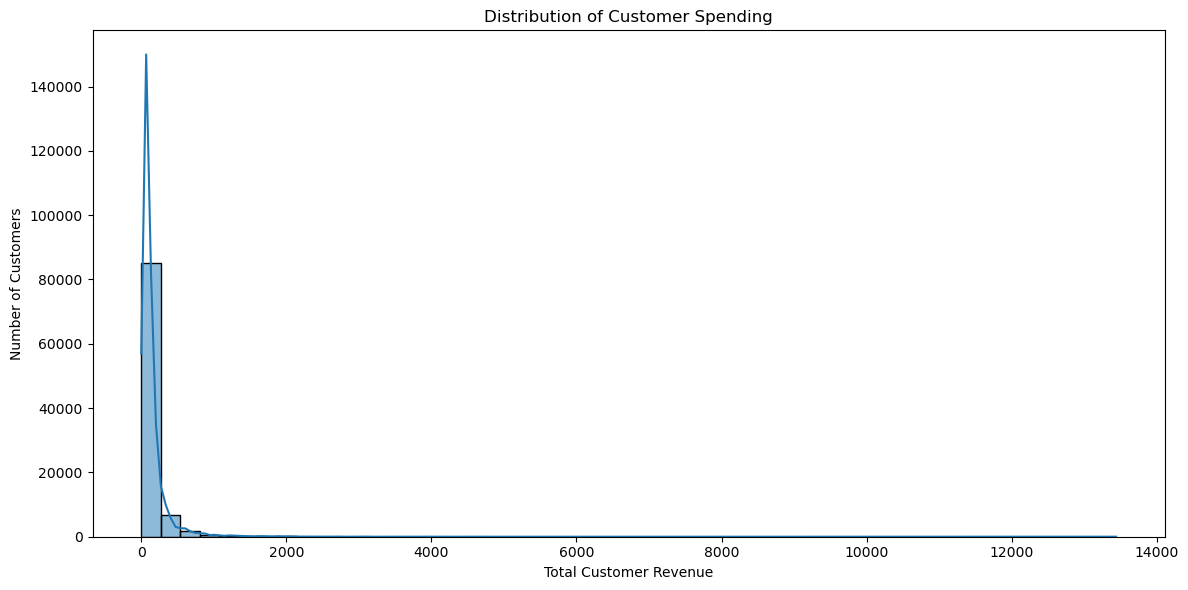

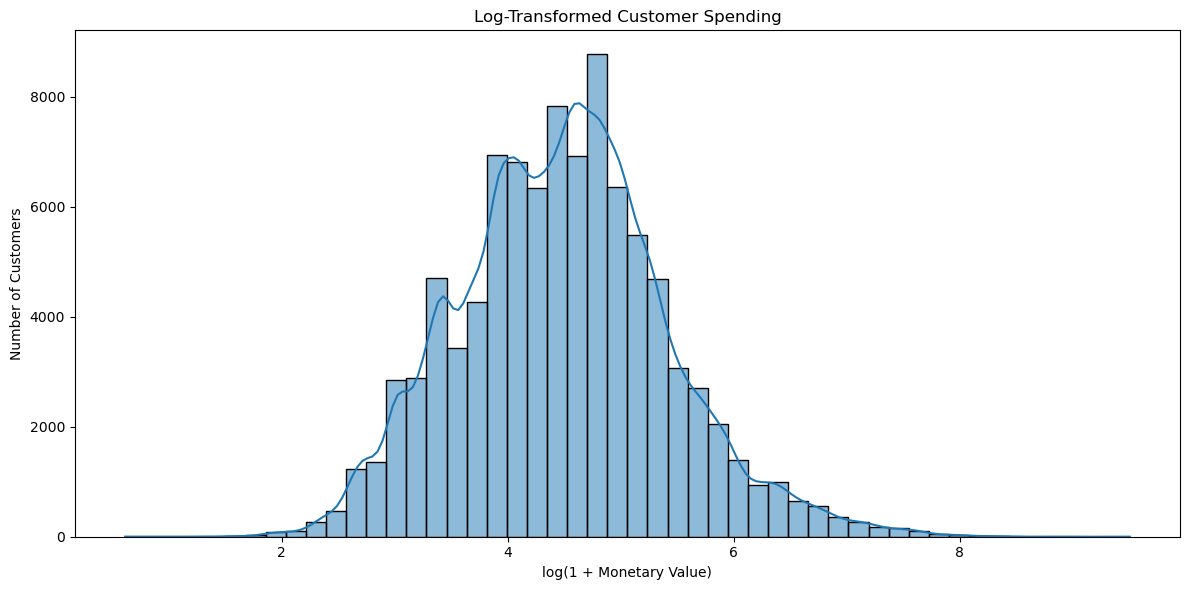

In [17]:
# =========================================================
# Log-transformed Customer Spending
# =========================================================

customer_summary['LogMonetaryValue'] = np.log1p(
    customer_summary['MonetaryValue']
)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=customer_summary,
    x='LogMonetaryValue',
    bins=50,
    kde=True
)

plt.title('Log-Transformed Customer Spending')
plt.xlabel('log(1 + Monetary Value)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [18]:
# =========================================================
# Final P18 Summary
# =========================================================

final_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Mean Spending',
        'Median Spending',
        'Standard Deviation',
        'Minimum Spending',
        'Maximum Spending',
        'Q1',
        'Q3',
        'IQR',
        'Lower Outlier Bound',
        'Upper Outlier Bound',
        'Number of Outliers',
        'Outlier Percentage'
    ],
    'Value': [
        total_customers,
        round(monetary.mean(), 2),
        round(monetary.median(), 2),
        round(monetary.std(), 2),
        round(monetary.min(), 2),
        round(monetary.max(), 2),
        round(q1, 2),
        round(q3, 2),
        round(iqr, 2),
        round(lower_bound, 2),
        round(upper_bound, 2),
        number_of_outliers,
        round(outlier_percentage, 2)
    ]
})

final_summary

,Metric,Value
0,Total Customers,95420.00
1,Mean Spending,142.44
2,Median Spending,89.90
3,Standard Deviation,217.66
4,Minimum Spending,0.85
5,Maximum Spending,13440.00
6,Q1,47.90
7,Q3,155.00
8,IQR,107.10
9,Lower Outlier Bound,-112.75


In [ ]:
## Customer Spending Distribution Insights

Customer spending is not evenly distributed across the customer base. The mean and median should be compared to determine whether higher-value customers are pulling the average upward. The boxplot and IQR analysis help identify unusually high-spending customers that may represent valuable customer segments. These high-value customers should be considered for retention and targeted marketing strategies.

In [25]:
# =========================================================
# Recreate CustomerSegment
# =========================================================

customer_summary['CustomerSegment'] = np.select(
    [
        (
            (customer_summary['RecencyDays'] <= 90) &
            (customer_summary['Frequency'] >= 3) &
            (customer_summary['MonetaryValue'] >= 500)
        ),

        (
            (customer_summary['RecencyDays'] > 180) &
            (customer_summary['Frequency'] == 1)
        )
    ],

    [
        'Champions',
        'At Risk'
    ],

    default='Regular Customers'
)

customer_summary['CustomerSegment'].value_counts()

CustomerSegment
At Risk              55823
Regular Customers    39578
Champions               19
Name: count, dtype: int64

In [26]:
# =========================================================
# P19: Compare Customer Spending Across RFM Segments
# =========================================================

segment_stats = (
    customer_summary
    .groupby('CustomerSegment')
    .agg(
        TotalCustomers=('customer_unique_id', 'nunique'),
        MeanMonetaryValue=('MonetaryValue', 'mean'),
        MedianMonetaryValue=('MonetaryValue', 'median'),
        StdMonetaryValue=('MonetaryValue', 'std'),
        MeanFrequency=('Frequency', 'mean'),
        MedianFrequency=('Frequency', 'median')
    )
    .reset_index()
)

# Round the results
segment_stats = segment_stats.round({
    'MeanMonetaryValue': 2,
    'MedianMonetaryValue': 2,
    'StdMonetaryValue': 2,
    'MeanFrequency': 2,
    'MedianFrequency': 2
})

segment_stats


,CustomerSegment,TotalCustomers,MeanMonetaryValue,MedianMonetaryValue,StdMonetaryValue,MeanFrequency,MedianFrequency
0,At Risk,55823,137.09,85.90,209.25,1.00,1.0
1,Champions,19,1058.80,700.27,825.58,4.53,4.0
2,Regular Customers,39578,149.55,94.90,227.28,1.08,1.0


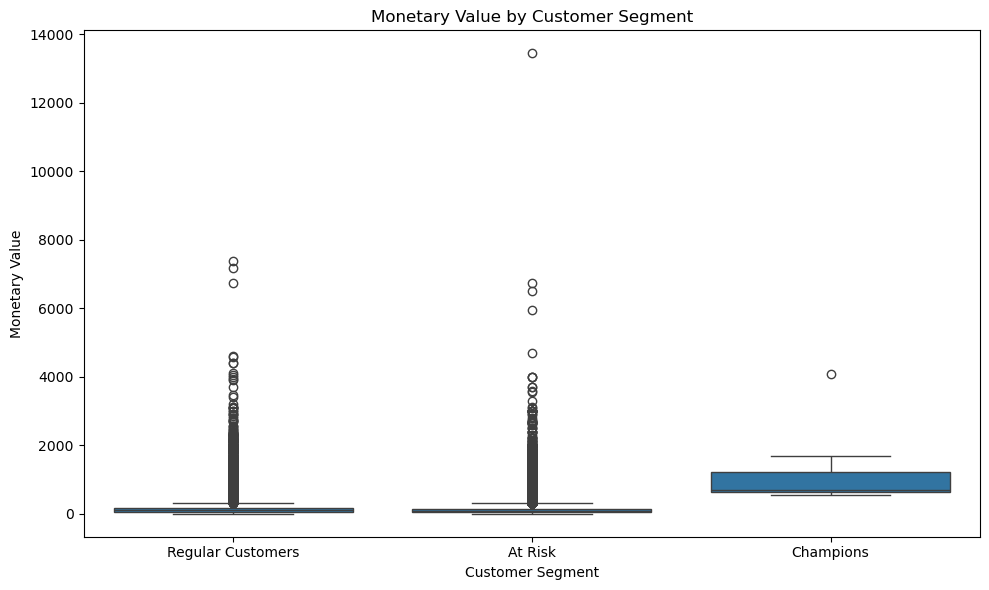

In [27]:
# =========================================================
# Monetary Value by Customer Segment
# =========================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=customer_summary,
    x='CustomerSegment',
    y='MonetaryValue'
)

plt.title('Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Monetary Value')

plt.tight_layout()
plt.show()

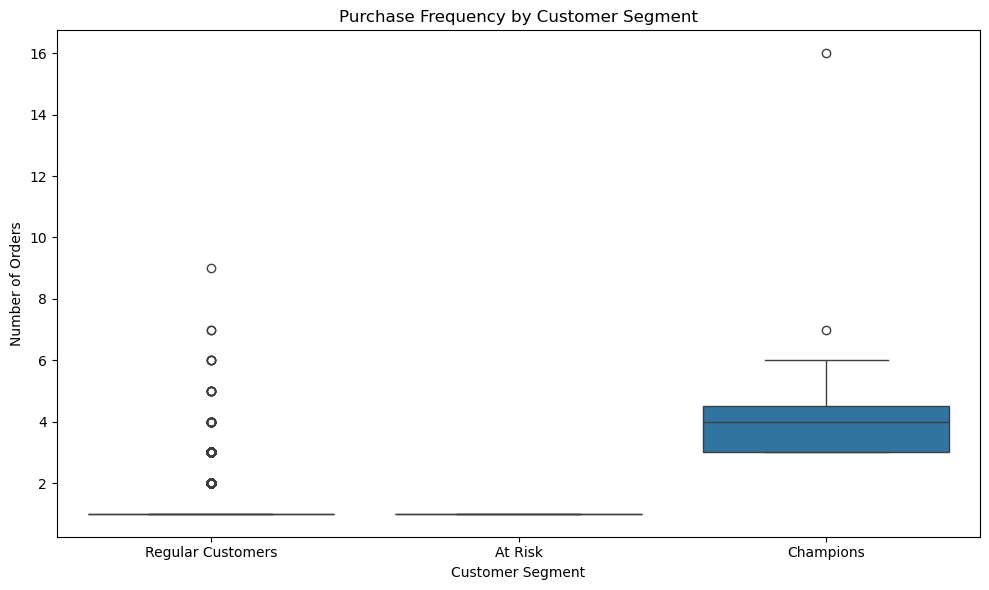

In [28]:
# =========================================================
# Frequency by Customer Segment
# =========================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=customer_summary,
    x='CustomerSegment',
    y='Frequency'
)

plt.title('Purchase Frequency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [29]:
# =========================================================
# P20: Correlation Analysis
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure these columns exist
print(
    customer_summary[
        ['RecencyDays', 'Frequency', 'MonetaryValue']
    ].head()
)

   RecencyDays  Frequency  MonetaryValue
0          115          1         129.90
1          118          1          18.90
2          541          1          69.00
3          325          1          25.99
4          292          1         180.00


In [30]:
# Correlation matrix

correlation_matrix = customer_summary[
    [
        'RecencyDays',
        'Frequency',
        'MonetaryValue'
    ]
].corr()

correlation_matrix

,RecencyDays,Frequency,MonetaryValue
RecencyDays,1.000000,-0.022352,0.000853
Frequency,-0.022352,1.000000,0.105980
MonetaryValue,0.000853,0.105980,1.000000


In [31]:
# Pearson correlation between purchase frequency
# and customer spending

frequency_revenue_corr = (
    customer_summary['Frequency']
    .corr(customer_summary['MonetaryValue'])
)

print(
    "Frequency vs Monetary Value Correlation:",
    round(frequency_revenue_corr, 3)
)

Frequency vs Monetary Value Correlation: 0.106


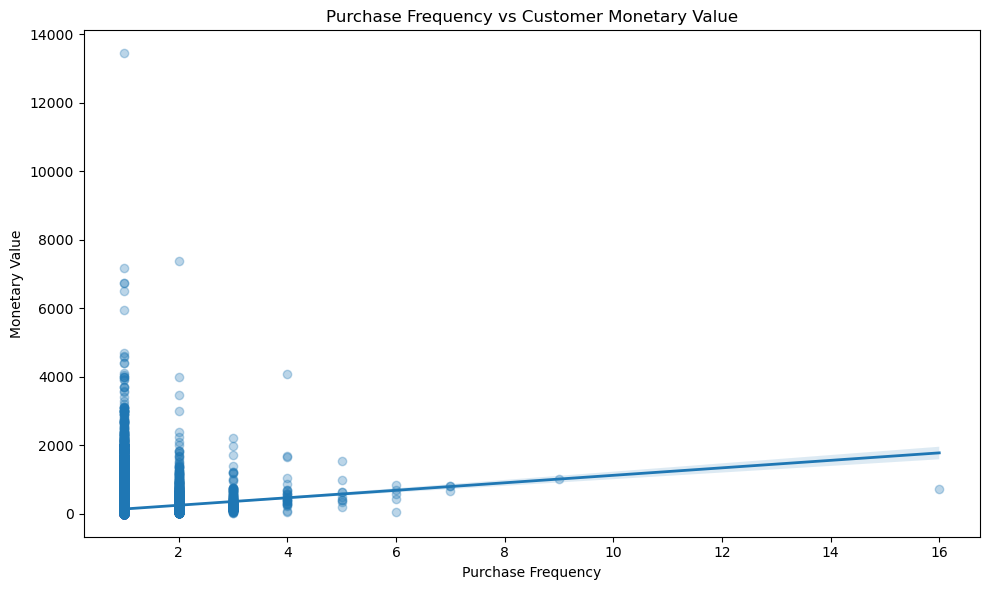

In [32]:
# =========================================================
# Frequency vs Monetary Value
# =========================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=customer_summary,
    x='Frequency',
    y='MonetaryValue',
    scatter_kws={'alpha': 0.3},
    line_kws={'linewidth': 2}
)

plt.title('Purchase Frequency vs Customer Monetary Value')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')

plt.tight_layout()
plt.show()

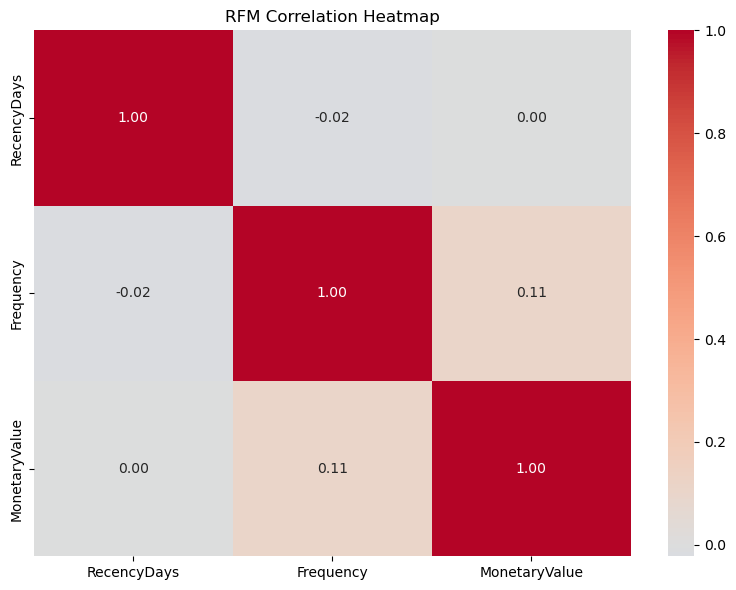

In [33]:
# =========================================================
# Correlation Heatmap
# =========================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('RFM Correlation Heatmap')

plt.tight_layout()
plt.show()

In [ ]:
## Correlation Insights

The correlation analysis examines the relationships among customer recency, purchase frequency, and monetary value. The correlation between purchase frequency and monetary value indicates whether customers who purchase more frequently also tend to generate more revenue. The heatmap provides an overall view of the direction and strength of the relationships among the RFM variables. The results can help identify which customer behaviors are most strongly associated with higher customer value.